# 第 10 章 · CLIP / InfoNCE 代码实验

[章节网页](../ch10.html)

## 运行内容

- 加载真实图片和文本 prompt
- 运行官方 CLIPModel
- 绘制图文匹配概率

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# CLIP 官方 API：用真实图片和文本提示计算图文匹配。
clip_packages = {
    "torch": "torch>=2.2",
    "transformers": "transformers>=4.40",
    "socksio": "socksio>=1.0",
}
missing = [package for module, package in clip_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
clip_model = CLIPModel.from_pretrained(model_id)
clip_model.eval()

clip_images = [
    Image.fromarray(load_sample_image("china.jpg")),
    Image.fromarray(load_sample_image("flower.jpg")),
]
image_names = ["china.jpg", "flower.jpg"]
text_prompts = [
    "a photo of a Chinese temple by a lake",
    "a close-up photo of a red flower",
    "a photo of a taxi cab",
    "a photo of a handwritten digit",
]

inputs = processor(text=text_prompts, images=clip_images, return_tensors="pt", padding=True)
with torch.no_grad():
    outputs = clip_model(**inputs)

logits = outputs.logits_per_image
probs = logits.softmax(dim=1)
targets = torch.tensor([0, 1])
clip_loss = F.cross_entropy(logits[:, :2], targets).item()

clip_prob_df = pd.DataFrame(probs.numpy(), index=image_names, columns=text_prompts)
display(clip_prob_df.round(3))
print("image-text contrastive loss:", round(float(clip_loss), 4))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


,a photo of a Chinese temple by a lake,a close-up photo of a red flower,a photo of a taxi cab,a photo of a handwritten digit
china.jpg,1.0,0.000,0.000,0.000
flower.jpg,0.0,0.993,0.006,0.001


image-text contrastive loss: 0.0001


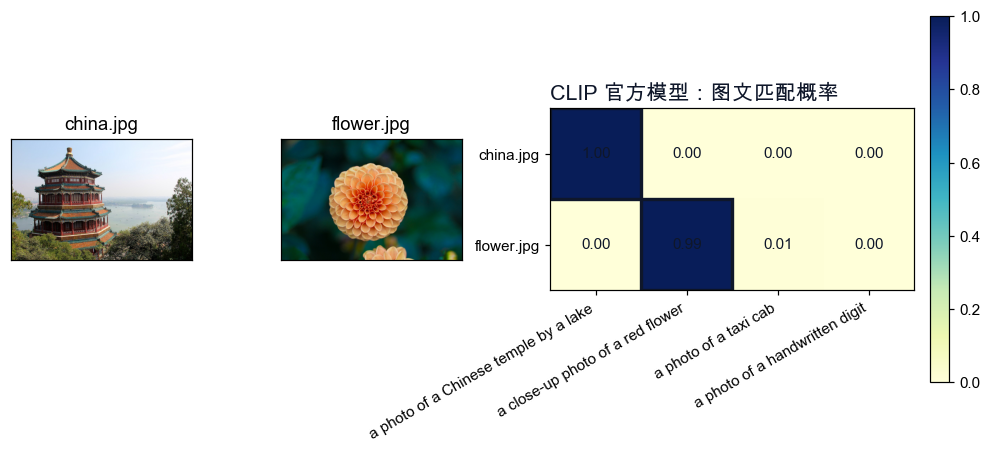

In [3]:
# 绘制真实图片和 CLIP 图文概率矩阵。
sim_matrix = probs.numpy()
fig = plt.figure(figsize=(11.0, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 2.2], wspace=0.35)

for idx, image in enumerate(clip_images):
    ax_img = fig.add_subplot(gs[0, idx])
    ax_img.imshow(image)
    ax_img.set_title(image_names[idx], fontweight="bold")
    ax_img.set_xticks([])
    ax_img.set_yticks([])

ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(sim_matrix, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(text_prompts)), text_prompts, rotation=30, ha="right")
ax.set_yticks(range(len(image_names)), image_names)
for i in range(len(image_names)):
    best = int(np.argmax(sim_matrix[i]))
    for j in range(len(text_prompts)):
        value = sim_matrix[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="#0f172a", fontweight="bold" if j == best else "normal")
        if j == best:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#0f172a", linewidth=2.2))
ax.set_title("CLIP 官方模型：图文匹配概率", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()